<a href="https://colab.research.google.com/github/cenna-alias/test/blob/main/logistic_regression_iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression Tutorial Notebook

## Objective
This notebook explains how to perform **Logistic Regression** using Python and Scikit-learn.

### Topics Covered
- Importing libraries
- Loading dataset
- Understanding the data
- Data preprocessing
- Splitting training and testing data
- Building Logistic Regression model
- Training the model
- Prediction
- Accuracy evaluation
- Confusion Matrix
- Classification Report

Dataset Used: **Iris Dataset**


In [ ]:
# Import required libraries

import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import dataset
from sklearn.datasets import load_iris

# Train-test split
from sklearn.model_selection import train_test_split

# Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
#from sklearn.datasets import load_wine

In [ ]:
data=load_iris()

In [ ]:
print(data)

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

In [ ]:
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add target column
df['target'] = data.target

# Display first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
df['target'].unique()

array([0, 1, 2])

In [ ]:
df['target'].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [ ]:
df.shape

(150, 5)

In [ ]:
print(data.DESCR[:1000])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

## Step 1: Load the Dataset

The Iris dataset contains flower measurements:
- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

Target Classes:
- Setosa
- Versicolor
- Virginica


In [ ]:
# Load iris dataset

iris = load_iris()

# Create DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add target column
df['target'] = iris.target

# Display first 5 rows
df.head()


## Step 2: Explore the Dataset

In [ ]:
# Shape of dataset
print("Shape of Dataset:", df.shape)
print("/n")
# Column names
print("\nColumns:\n", df.columns)
print("/n")
# Check missing values
print("\nMissing Values:\n")
print(df.isnull().sum())


Shape of Dataset: (150, 5)
/n

Columns:
 Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')
/n

Missing Values:

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [ ]:
df['target'].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

## Step 3: Define Features and Target Variable

- Features (X) → Input columns
- Target (y) → Output column


In [ ]:
# Features
X = df.drop('target', axis=1)

# Target
y = df['target']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)


Features Shape: (150, 4)
Target Shape: (150,)


## Step 4: Split the Dataset

The dataset is divided into:
- Training Data → Used to train the model
- Testing Data → Used to evaluate the model


In [ ]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)
print("Training Data Shape:", y_train.shape)
print("Testing Data Shape:", y_test.shape)

Training Data Shape: (120, 4)
Testing Data Shape: (30, 4)
Training Data Shape: (120,)
Testing Data Shape: (30,)


## Step 5: Create Logistic Regression Model

In [ ]:
# Create model

model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)

print("Model Training Completed")


Model Training Completed


In [ ]:
print(X_test)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
73                 6.1               2.8                4.7               1.2
18                 5.7               3.8                1.7               0.3
118                7.7               2.6                6.9               2.3
78                 6.0               2.9                4.5               1.5
76                 6.8               2.8                4.8               1.4
31                 5.4               3.4                1.5               0.4
64                 5.6               2.9                3.6               1.3
141                6.9               3.1                5.1               2.3
68                 6.2               2.2                4.5               1.5
82                 5.8               2.7                3.9               1.2
110                6.5               3.2                5.1               2.0
12                 4.8               3.0                1.4     

In [ ]:
print(y_test)

73     1
18     0
118    2
78     1
76     1
31     0
64     1
141    2
68     1
82     1
110    2
12     0
36     0
9      0
19     0
56     1
104    2
69     1
55     1
132    2
29     0
127    2
26     0
128    2
131    2
145    2
108    2
143    2
45     0
30     0
Name: target, dtype: int32


## Step 6: Make Predictions

In [ ]:
# Predict on test data

y_pred = model.predict(X_test)

# Display predictions
print("Predicted Values:\n", y_pred)


Predicted Values:
 [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


## Step 7: Evaluate the Model

In [ ]:
# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)


Accuracy Score: 1.0


## Step 8: Confusion Matrix

Confusion Matrix:

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


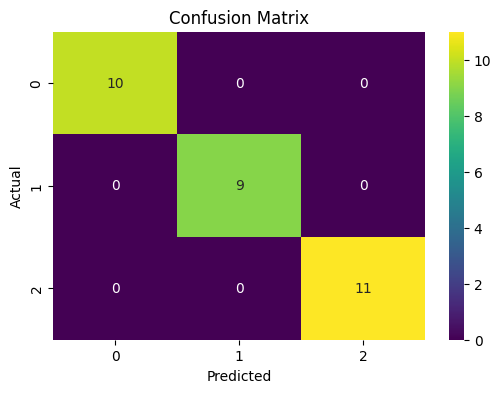

In [ ]:
# Create confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


## Step 9: Classification Report

In [ ]:
# Print classification report

report = classification_report(y_test, y_pred)

print(report)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

